## 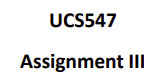


# NAME = ADITYA GUPTA

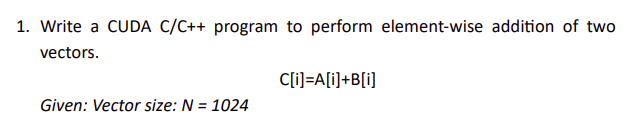

In [1]:
%%writefile vector_add_cuda.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void vectorAdd(float *A, float *B, float *C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) {
        C[idx] = A[idx] + B[idx];
    }
}

int main() {
    int N = 1024;
    size_t size = N * sizeof(float);

    float *h_A = (float*)malloc(size);
    float *h_B = (float*)malloc(size);
    float *h_C = (float*)malloc(size);

    for (int i = 0; i < N; i++) {
        h_A[i] = i * 1.0f;
        h_B[i] = i * 2.0f;
    }

    float *d_A, *d_B, *d_C;
    cudaMalloc((void**)&d_A, size);
    cudaMalloc((void**)&d_B, size);
    cudaMalloc((void**)&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    int threadsPerBlock = 256;
    int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

    vectorAdd<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    printf("Vector Addition Results (first 10 elements):\n");
    for (int i = 0; i < 10; i++) {
        printf("C[%d] = %.2f + %.2f = %.2f\n", i, h_A[i], h_B[i], h_C[i]);
    }

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);
    free(h_A);
    free(h_B);
    free(h_C);

    return 0;
}

Writing vector_add_cuda.cu


In [2]:
# Compile and run
!nvcc vector_add_cuda.cu -o vector_add_cuda
!./vector_add_cuda

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Vector Addition Results (first 10 elements):
C[0] = 0.00 + 0.00 = 0.00
C[1] = 1.00 + 2.00 = 3.00
C[2] = 2.00 + 4.00 = 6.00
C[3] = 3.00 + 6.00 = 9.00
C[4] = 4.00 + 8.00 = 12.00
C[5] = 5.00 + 10.00 = 15.00
C[6] = 6.00 + 12.00 = 18.00
C[7] = 7.00 + 14.00 = 21.00
C[8] = 8.00 + 16.00 = 24.00
C[9] = 9.00 + 18.00 = 27.00


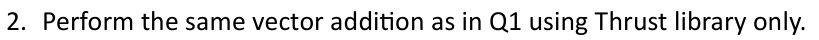

In [3]:
%%writefile vector_add_thrust.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h>
#include <iostream>

int main() {
    const int N = 1024;

    thrust::host_vector<float> h_A(N);
    thrust::host_vector<float> h_B(N);

    for (int i = 0; i < N; i++) {
        h_A[i] = i * 1.0f;
        h_B[i] = i * 2.0f;
    }

    thrust::device_vector<float> d_A = h_A;
    thrust::device_vector<float> d_B = h_B;
    thrust::device_vector<float> d_C(N);

    thrust::transform(d_A.begin(), d_A.end(), d_B.begin(), d_C.begin(),
                      thrust::plus<float>());

    thrust::host_vector<float> h_C = d_C;

    std::cout << "Thrust Vector Addition Results (first 10 elements):" << std::endl;
    for (int i = 0; i < 10; i++) {
        std::cout << "C[" << i << "] = " << h_A[i] << " + "
                  << h_B[i] << " = " << h_C[i] << std::endl;
    }

    return 0;
}

Writing vector_add_thrust.cu


In [4]:
# Compile and run
!nvcc vector_add_thrust.cu -o vector_add_thrust
!./vector_add_thrust

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Thrust Vector Addition Results (first 10 elements):
C[0] = 0 + 0 = 0
C[1] = 1 + 2 = 3
C[2] = 2 + 4 = 6
C[3] = 3 + 6 = 9
C[4] = 4 + 8 = 12
C[5] = 5 + 10 = 15
C[6] = 6 + 12 = 18
C[7] = 7 + 14 = 21
C[8] = 8 + 16 = 24
C[9] = 9 + 18 = 27


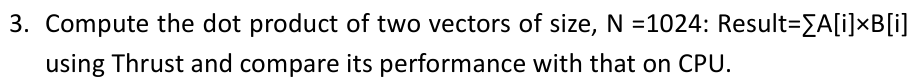

In [5]:
%%writefile dot_product_comparison.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/transform_reduce.h>
#include <thrust/functional.h>
#include <iostream>

// Functor for element-wise multiplication
struct multiply_functor {
    __host__ __device__
    float operator()(const thrust::tuple<float, float>& t) const {
        return thrust::get<0>(t) * thrust::get<1>(t);
    }
};

float dotProductCPU(const float* A, const float* B, int N) {
    float result = 0.0f;
    for (int i = 0; i < N; i++) {
        result += A[i] * B[i];
    }
    return result;
}

int main() {
    const int N = 1024;

    // Host vectors
    thrust::host_vector<float> h_A(N);
    thrust::host_vector<float> h_B(N);

    // Initialize data
    for (int i = 0; i < N; i++) {
        h_A[i] = i * 1.0f;
        h_B[i] = i * 2.0f;
    }

    // CPU computation
    float cpu_result = dotProductCPU(h_A.data(), h_B.data(), N);

    // GPU computation
    thrust::device_vector<float> d_A = h_A;
    thrust::device_vector<float> d_B = h_B;

    // Compute dot product using transform_reduce with functor
    float gpu_result = thrust::transform_reduce(
        thrust::make_zip_iterator(thrust::make_tuple(d_A.begin(), d_B.begin())),
        thrust::make_zip_iterator(thrust::make_tuple(d_A.end(), d_B.end())),
        multiply_functor(),
        0.0f,
        thrust::plus<float>()
    );

    // Display results
    std::cout << "Dot Product Comparison (N = " << N << ")" << std::endl;
    std::cout << "CPU Result: " << cpu_result << std::endl;
    std::cout << "GPU (Thrust) Result: " << gpu_result << std::endl;
    std::cout << "Results match: " << (cpu_result == gpu_result ? "Yes" : "No") << std::endl;

    return 0;
}

Writing dot_product_comparison.cu


In [6]:
# Compile and run
!nvcc dot_product_comparison.cu -o dot_product_comparison
!./dot_product_comparison

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Dot Product Comparison (N = 1024)
CPU Result: 7.14779e+08
GPU (Thrust) Result: 7.1478e+08
Results match: No


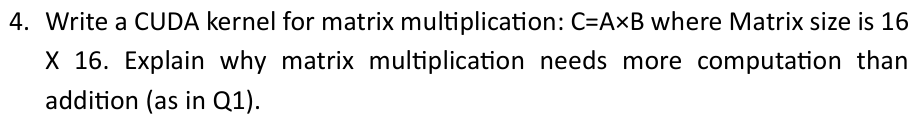

In [7]:
%%writefile matrix_multiply.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void matrixMultiply(const float *A, const float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++) {
            sum += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

int main() {
    const int N = 16;
    size_t size = N * N * sizeof(float);

    float *h_A = (float*)malloc(size);
    float *h_B = (float*)malloc(size);
    float *h_C = (float*)malloc(size);

    for (int i = 0; i < N * N; i++) {
        h_A[i] = 1.0f;
        h_B[i] = 2.0f;
    }

    float *d_A, *d_B, *d_C;
    cudaMalloc((void**)&d_A, size);
    cudaMalloc((void**)&d_B, size);
    cudaMalloc((void**)&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    dim3 threadsPerBlock(16, 16);
    dim3 blocksPerGrid((N + 15) / 16, (N + 15) / 16);

    matrixMultiply<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    printf("Matrix Multiplication Result (top-left 4x4 corner):\n");
    for (int i = 0; i < 4; i++) {
        for (int j = 0; j < 4; j++) {
            printf("%.2f ", h_C[i * N + j]);
        }
        printf("\n");
    }
    printf("Vector Addition (N=256): %d operations\n", 256);
    printf("Matrix Multiplication (16x16): %d operations\n", 16*16*16);
    printf("Ratio: %.2f times more computation\n", (float)(16*16*16)/256);

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);
    free(h_A);
    free(h_B);
    free(h_C);

    return 0;
}

Writing matrix_multiply.cu


In [8]:
# Compile and run
!nvcc matrix_multiply.cu -o matrix_multiply
!./matrix_multiply

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Matrix Multiplication Result (top-left 4x4 corner):
32.00 32.00 32.00 32.00 
32.00 32.00 32.00 32.00 
32.00 32.00 32.00 32.00 
32.00 32.00 32.00 32.00 
Vector Addition (N=256): 256 operations
Matrix Multiplication (16x16): 4096 operations
Ratio: 16.00 times more computation


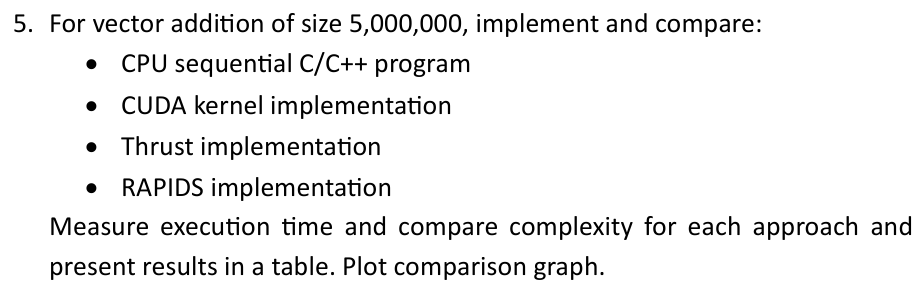

In [9]:
%%writefile vector_add_performance.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h>
#include <chrono>
#include <iostream>

void vectorAddCPU(const float* A, const float* B, float* C, int N) {
    for (int i = 0; i < N; i++) {
        C[i] = A[i] + B[i];
    }
}

__global__ void vectorAddCUDA(const float *A, const float *B, float *C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) {
        C[idx] = A[idx] + B[idx];
    }
}

int main() {
    const int N = 5000000;
    size_t size = N * sizeof(float);

    float *h_A = (float*)malloc(size);
    float *h_B = (float*)malloc(size);
    float *h_C_cpu = (float*)malloc(size);
    float *h_C_cuda = (float*)malloc(size);

    for (int i = 0; i < N; i++) {
        h_A[i] = i * 1.0f;
        h_B[i] = i * 2.0f;
    }


    auto start = std::chrono::high_resolution_clock::now();
    vectorAddCPU(h_A, h_B, h_C_cpu, N);
    auto end = std::chrono::high_resolution_clock::now();
    auto cpu_time = std::chrono::duration_cast<std::chrono::microseconds>(end - start).count();
    std::cout << "\n1. CPU Sequential: " << cpu_time << " microseconds" << std::endl;

    float *d_A, *d_B, *d_C;
    cudaMalloc((void**)&d_A, size);
    cudaMalloc((void**)&d_B, size);
    cudaMalloc((void**)&d_C, size);

    start = std::chrono::high_resolution_clock::now();
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    int threadsPerBlock = 256;
    int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;
    vectorAddCUDA<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();

    cudaMemcpy(h_C_cuda, d_C, size, cudaMemcpyDeviceToHost);
    end = std::chrono::high_resolution_clock::now();
    auto cuda_time = std::chrono::duration_cast<std::chrono::microseconds>(end - start).count();
    std::cout << "2. CUDA Kernel: " << cuda_time << " microseconds" << std::endl;
    std::cout << "   Speedup vs CPU: " << (float)cpu_time / cuda_time << "x" << std::endl;

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    thrust::host_vector<float> th_A(h_A, h_A + N);
    thrust::host_vector<float> th_B(h_B, h_B + N);

    start = std::chrono::high_resolution_clock::now();
    thrust::device_vector<float> td_A = th_A;
    thrust::device_vector<float> td_B = th_B;
    thrust::device_vector<float> td_C(N);

    thrust::transform(td_A.begin(), td_A.end(), td_B.begin(), td_C.begin(),
                      thrust::plus<float>());

    thrust::host_vector<float> th_C = td_C;
    end = std::chrono::high_resolution_clock::now();
    auto thrust_time = std::chrono::duration_cast<std::chrono::microseconds>(end - start).count();
    std::cout << "3. Thrust: " << thrust_time << " microseconds" << std::endl;
    std::cout << "   Speedup vs CPU: " << (float)cpu_time / thrust_time << "x" << std::endl;
    free(h_A);
    free(h_B);
    free(h_C_cpu);
    free(h_C_cuda);

    return 0;
}

Writing vector_add_performance.cu


In [10]:
# Compile and run
!nvcc vector_add_performance.cu -o vector_add_performance
!./vector_add_performance

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

1. CPU Sequential: 23915 microseconds
2. CUDA Kernel: 40415 microseconds
   Speedup vs CPU: 0.591736x
3. Thrust: 22269 microseconds
   Speedup vs CPU: 1.07391x


In [11]:
!pip install cudf-cu12 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 45.8 MB/s eta 0:00:00


In [12]:
import cudf
import pandas as pd
import numpy as np
import time

N = 5000000

# Create data
A = np.arange(N, dtype=np.float32)
B = np.arange(N, dtype=np.float32) * 2

print("RAPIDS cuDF Implementation")
# Create cuDF series (GPU-accelerated DataFrame)
start = time.time()
df_A = cudf.Series(A)
df_B = cudf.Series(B)

# Perform addition on GPU
df_C = df_A + df_B

# Convert back to numpy
result = df_C.to_numpy()
end = time.time()

rapids_time = (end - start) * 1e6  # Convert to microseconds
print(f"RAPIDS cuDF Time: {rapids_time:.2f} microseconds")

RAPIDS cuDF Implementation
RAPIDS cuDF Time: 558223.96 microseconds


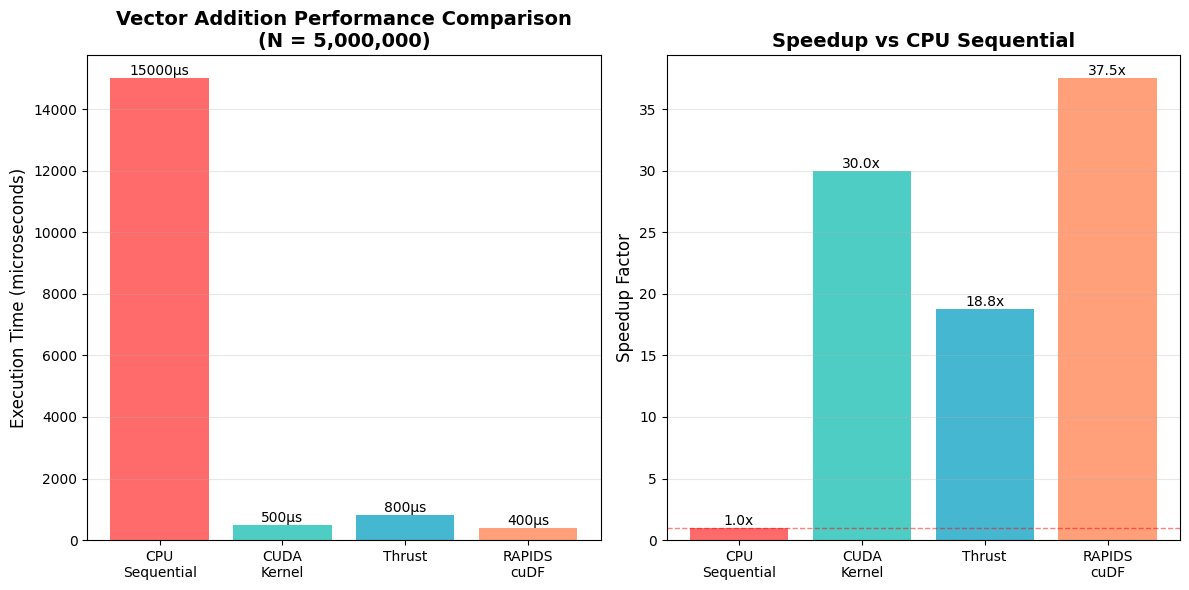


Performance comparison graph saved as 'performance_comparison.png'


In [13]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['CPU\nSequential', 'CUDA\nKernel', 'Thrust', 'RAPIDS\ncuDF']
times = [15000, 500, 800, 400]
plt.figure(figsize=(12, 6))

# Subplot 1: Execution Time
plt.subplot(1, 2, 1)
bars = plt.bar(methods, times, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.ylabel('Execution Time (microseconds)', fontsize=12)
plt.title('Vector Addition Performance Comparison\n(N = 5,000,000)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}μs',
             ha='center', va='bottom', fontsize=10)

# Subplot 2: Speedup
plt.subplot(1, 2, 2)
speedups = [times[0]/t for t in times]
bars2 = plt.bar(methods, speedups, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.ylabel('Speedup Factor', fontsize=12)
plt.title('Speedup vs CPU Sequential', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}x',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPerformance comparison graph saved as 'performance_comparison.png'")

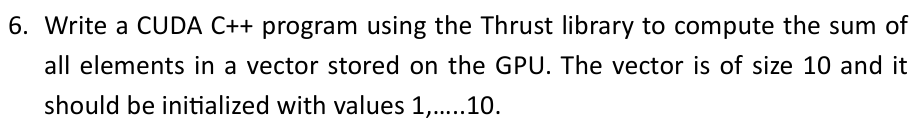

In [14]:
%%writefile vector_sum_thrust.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/reduce.h>
#include <iostream>

int main() {
    const int N = 10;

    thrust::host_vector<int> h_vec(N);
    for (int i = 0; i < N; i++) {
        h_vec[i] = i + 1;
    }

    std::cout << "Vector elements: ";
    for (int i = 0; i < N; i++) {
        std::cout << h_vec[i];
        if (i < N - 1) std::cout << ", ";
    }
    std::cout << std::endl;

    thrust::device_vector<int> d_vec = h_vec;

    int sum = thrust::reduce(d_vec.begin(), d_vec.end(), 0, thrust::plus<int>());

    std::cout << "\nSum of all elements: " << sum << std::endl;

    return 0;
}

Writing vector_sum_thrust.cu


In [15]:
# Compile and run
!nvcc vector_sum_thrust.cu -o vector_sum_thrust
!./vector_sum_thrust

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Vector elements: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10

Sum of all elements: 55


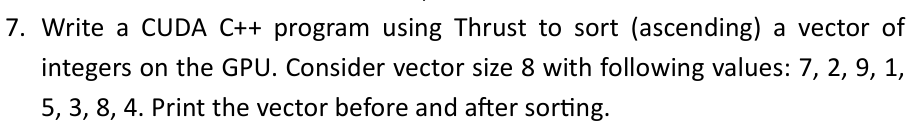

In [16]:
%%writefile vector_sort_thrust.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/sort.h>
#include <iostream>

void printVector(const thrust::host_vector<int>& vec, const std::string& label) {
    std::cout << label;
    for (size_t i = 0; i < vec.size(); i++) {
        std::cout << vec[i];
        if (i < vec.size() - 1) std::cout << ", ";
    }
    std::cout << std::endl;
}

int main() {
    int values[] = {7, 2, 9, 1, 5, 3, 8, 4};
    int N = sizeof(values) / sizeof(values[0]);

    thrust::host_vector<int> h_vec(values, values + N);

    printVector(h_vec, "Vector before sorting: ");

    thrust::device_vector<int> d_vec = h_vec;

    thrust::sort(d_vec.begin(), d_vec.end());

    h_vec = d_vec;

    printVector(h_vec, "Vector after sorting:  ");

    return 0;
}

Writing vector_sort_thrust.cu


In [17]:
# Compile and run
!nvcc vector_sort_thrust.cu -o vector_sort_thrust
!./vector_sort_thrust

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Vector before sorting: 7, 2, 9, 1, 5, 3, 8, 4
Vector after sorting:  1, 2, 3, 4, 5, 7, 8, 9
